In [1]:
from bokeh.plotting import figure
from bokeh.models import Span
from bokeh.io import show, output_notebook
output_notebook()
import numpy as np
import biocircuits

import scipy

from typing import Callable

Loading BokehJS ...

# Figure 1

## B

In [25]:
# Pulse
def pulse(t, t0, t1, J):
    return J * (t >= t0) * (t <= t1) / (t1 - t0)

# Parameters
t0 = 0 # seconds
t1 = 0.2 # seconds
J = 1.0 # amplitude * seconds

# Time Spacing
t = np.linspace(-0.4, 15, 1000)

# Compute the pulse
input = pulse(t, t0, t1, J)

# Plot the pulse
input_plot = figure(width=400, height=100, y_axis_label = 'Input', x_axis_label = 'Time (s)')
input_plot.yaxis.major_tick_line_color = None
input_plot.yaxis.minor_tick_line_color = None
input_plot.yaxis.major_label_text_font_size = '0pt'
input_plot.line(t, input, line_width=2)
show(input_plot)

In [30]:
# Basis functions
def basis_function(t, tau, n):
    return (t>0) * ((t/tau)**n) * np.exp(-t/tau) / scipy.special.factorial(n)

# Parameters
tau = 0.1 # seconds

# Plot a few basis functions: 1, 8, 15, .., 99
basis_plot = figure(width=400, height=300, y_axis_label = r'Basis Functions \[g_n\]', x_axis_label = 'Time (s)')
for n in range(1, 100, 7):
    g_n = basis_function(t, tau, n)
    basis_plot.line(t, J * g_n, line_width=2)

show(basis_plot)

In [117]:
# Weighted sum of basis functions
def weighted_sum(t, tau, weights):
    return sum(w * basis_function(t, tau, n) for n, w in enumerate(weights))

# uniform weights
uniform_weights = J * np.ones(100)

# Optimal weights
optimization_times = np.linspace(0, 10, 1000)
def objective_function(s):
    output = weighted_sum(optimization_times, tau, s)
    return np.sum((output - 1)**2)
optimal_weights = scipy.optimize.minimize(objective_function, uniform_weights, bounds=[(-5, 5) for _ in range(len(uniform_weights))]).x
print("Optimal weights:", optimal_weights)

# Compute the weighted sum
uniform_output = weighted_sum(t, tau, uniform_weights)
optimal_output = weighted_sum(t, tau, optimal_weights)

# Plot the weighted sum
output_plot = figure(width=400, height=300, y_axis_label = r'Output \[r_{out}\]', x_axis_label = 'Time (s)')
output_plot.line(t, uniform_output, line_width=2, legend_label='Uniform Weights', color='blue')
output_plot.line(t, optimal_output, line_width=2, legend_label='Optimal Weights', color='red')
output_plot.legend.location = "bottom_left"
show(output_plot)

Optimal weights: [ 1.00181464  1.02124453  0.93282588  1.04050319  0.99900566  0.96901578
  1.02836343  1.07700334  1.03255016  0.92893449  0.86335664  0.8996739
  1.02074825  1.14897507  1.20279594  1.1458308   1.00315019  0.84328076
  0.74166818  0.74578136  0.85668907  1.03184449  1.20472952  1.31129184
  1.31275535  1.2075261   1.02956446  0.83549824  0.68576378  0.62619526
  0.67524254  0.81993883  1.02078581  1.22347627  1.37373466  1.43127324
  1.37951734  1.22901539  1.01424353  0.78496277  0.59453856  0.48782921
  0.49142165  0.6081487   0.8166914   1.07620839  1.33479558  1.53987984
  1.64857056  1.63591812  1.49966742  1.26074494  0.95949606  0.64854236
  0.38351933  0.21335336  0.17179498  0.27151339  0.50170535  0.82955455
  1.20522636  1.56957838  1.86334077  2.03637694  2.05557571  1.9102831
  1.61437633  1.20484848  0.73696861  0.27680229 -0.107912   -0.35723362
 -0.42759832 -0.29832423  0.02483785  0.50950304  1.09998935  1.72361629
  2.29936994  2.7477339   3.00066139

In [ ]:
# Varying inputs

# Feed Forward

- For feed-forward, we are governed by two equations
$$ \tau \frac{\mathrm{d}R_i}{\mathrm{d}t} = - R_i + R_{i-1} $$
$$ \tau \frac{\mathrm{d}r_{out}}{\mathrm{d}t} = - R_{out} + \sum_i W_i R_i $$

In [2]:
def dynamics(
    t: float,
    x: np.ndarray,
    W: np.ndarray,
    tau: float,
    input: Callable[[float], float]
) -> np.ndarray:
  """
  Computes the time derivative of the state vector x given the weight matrix W and input function.
  """
  dx = np.zeros_like(x)

  dx[0] = input(t) - x[0]

  dx[1:-1] = x[0:-2] - x[1:-1]

  dx[-1] = W[0] * input(t) + np.dot(W[1:], x[:-1]) - x[-1]

  return dx / tau

In [7]:
def pulse(t: float) -> float:
  """
  A simple pulse input function that is 10 for t in [0, 0.1] and 0 otherwise.
  """
  return 1.0 if 0 <= t <= 0.1 else 0.0

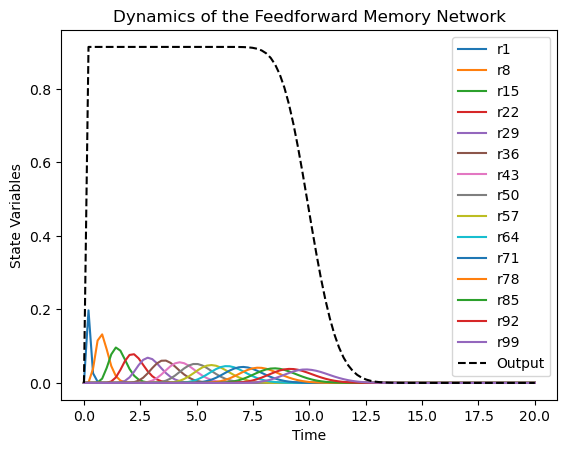

In [8]:
n = 100
tau = 0.1
W = np.ones(n)
x0 = np.zeros(n)
t_span = (0, 2*n*tau)
t_eval = np.linspace(*t_span, 100)
solution = solve_ivp(
    fun=lambda t, x: dynamics(t, x, W, tau, pulse),
    t_span=t_span,
    y0=x0,
    t_eval=t_eval
)

import matplotlib.pyplot as plt
plt.plot(solution.t, solution.y.T[:,::7])
plt.plot(solution.t, solution.y.T[:,-1], 'k--', label='Output')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.title('Dynamics of the Feedforward Memory Network')
plt.legend([f'r{i}' for i in range(1,n,7)] + ['Output'])
plt.show()

$$ r_n = \frac{1}{n!} \hat{t}^n e^{-\hat t} $$

We want to find optimal weights?